<a href="https://colab.research.google.com/github/Grace-Wanja/AI-MODEL-TRAINING-AND-TESTING/blob/main/Week_3_Numerical_Approximation_Gradients_Integration_PRACTICE_COLAB_vers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Teaching + Practice Notebook
## Approximation, Numerical Gradients and Numerical Integration

**Numerical Computing, Machine Learning and Optimization**

This notebook is designed to be both a **teaching resource** and a **practice resource**.  
The code is important, but the main goal is to understand the numerical ideas behind the code:

- what quantity we are trying to estimate;
- why an approximation is needed;
- what assumptions the method makes;
- how the mathematics relates to the code;
- how to interpret the numerical result;
- and how the ideas connect to machine learning and optimization.

The running physical example uses **invented campus solar-power data** for teaching.

> **Important habit:** distinguish a measured value from an estimated value.  
> A useful numerical estimate does not become a new independent observation.

## The story of the notebook

We begin with a small set of measurements and progressively ask more demanding questions:

$$
\boxed{\text{Samples}}
\rightarrow
\boxed{\text{Estimate a missing value}}
\rightarrow
\boxed{\text{Estimate a rate of change}}
\rightarrow
\boxed{\text{Study numerical error}}
\rightarrow
\boxed{\text{Apply derivatives to ML loss}}
\rightarrow
\boxed{\text{Verify gradients}}
\rightarrow
\boxed{\text{Estimate accumulation}}
$$

| Question | Numerical idea |
|---|---|
| What was the missing noon power? | Interpolation |
| How quickly was power changing near noon? | Numerical differentiation |
| How reliable is the derivative estimate? | Truncation and floating-point error |
| How does model loss change when a parameter changes? | Numerical gradient |
| How can we check gradient code independently? | Gradient verification |
| How much energy was generated over time? | Numerical integration |

As you work, repeatedly ask:

> **What are we estimating? Why do we need the method? What assumptions make the result trustworthy?**

## 0. Setup and learning goals

We use only **NumPy** and **Matplotlib**, so the notebook runs directly in Google Colab.

By the end, you should be able to:

1. distinguish observations from numerical estimates;
2. use linear interpolation and state its assumption;
3. explain the difference between a secant slope and a tangent slope;
4. implement forward, backward and central finite differences;
5. explain why central difference is usually more accurate for smooth functions;
6. explain why making $h$ extremely small can make a derivative estimate worse;
7. connect a physical derivative such as $dP/dt$ to an ML derivative such as $dJ/dw$;
8. interpret the sign of a gradient and use it in a gradient-descent update;
9. use numerical differentiation to check an analytic gradient;
10. estimate accumulated energy with the trapezoidal rule and compare it with Simpson's rule on a known-answer benchmark.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=10, suppress=False)

print("NumPy version:", np.__version__)
print("Notebook setup complete.")

NumPy version: 2.1.3
Notebook setup complete.


# Part I - From sampled measurements to a numerical derivative

## 1. Campus solar dataset: what information do we actually have?

A physical quantity such as solar power changes continuously with time, but a sensor records only selected samples.

For this teaching example, the measured data are:

$$
(10,420),\quad (11,510),\quad (13,680),\quad (14,620),
$$

where time is measured in hours and power in watts.

There is **no measured value at 12:00**.

This distinction matters:

- the physical process exists between measurements;
- the sensor gives us only discrete observations;
- numerical methods use those observations to estimate quantities that were not directly measured.

### Before running the next cell

Look at the time values. What tells you immediately that a measurement is missing?

Every other reading is one hour apart, so the sensor's rhythm is hourly but there is a jump from 11 to 13 which breaks that rhythm, meaning a 12:00 reading should be there but isn't.

Times: [10. 11. 13. 14.]
Time differences: [1. 2. 1.]


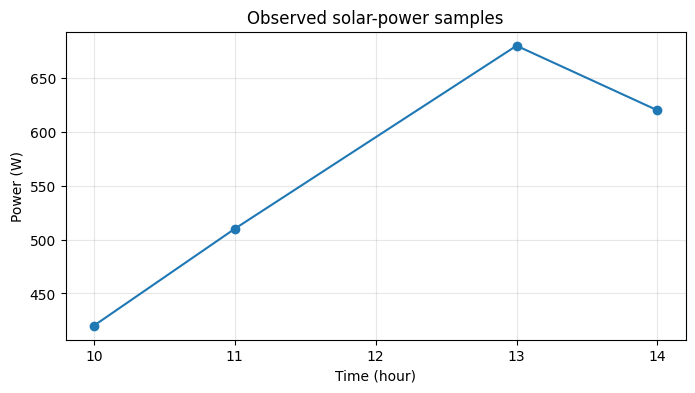

In [3]:
time = np.array([10., 11., 13., 14.])
power = np.array([420., 510., 680., 620.])

print("Times:", time)
print("Time differences:", np.diff(time))

plt.figure(figsize=(8, 4))
plt.plot(time, power, 'o-')
plt.xlabel('Time (hour)')
plt.ylabel('Power (W)')
plt.xticks([10, 11, 12, 13, 14])
plt.title('Observed solar-power samples')
plt.grid(True, alpha=0.3)
plt.show()

### Practice: interpret the dataset

Write a short answer in a new Markdown cell:

1. Which time is missing?
- 12
2. Are the four power values observations or estimates?
- Observations because they came directly from the sensor.
3. Why would it be incorrect to invent a noon value and then call it a sensor measurement?
- Because nobody measured it. Any noon value we produce is a guess based on an assumption. If we label it a measurement, anyone using the data later will trust it as much as the real readings, even though it could be wrong.

## 2. Linear interpolation: estimating a value inside the observed interval

### What are we trying to find?

We want an estimate of the missing power at 12:00.

### Why can we estimate it?

We know the values immediately before and after noon:

$$
P(11)=510\text{ W}, \qquad P(13)=680\text{ W}.
$$

Linear interpolation assumes that, **between these two samples**, the quantity changes approximately along a straight line.

The general linear-interpolation formula is

$$
P(t)=P_0+
\frac{t-t_0}{t_1-t_0}(P_1-P_0).
$$

The fraction

$$
\frac{t-t_0}{t_1-t_0}
$$

has an intuitive meaning: it tells us **how far through the interval** the target point lies.

At noon,

$$
\frac{12-11}{13-11}=\frac{1}{2}.
$$

So noon is halfway through the time interval, and the linear estimate is halfway through the corresponding power change.

### Where is interpolation useful?

Sensor data, lookup tables, resampling, graphics, scientific datasets and any situation where a value is needed **inside** a known interval.

In [4]:
t0, p0 = 11., 510.
t1, p1 = 13., 680.
t = 12.

fraction_through_interval = (t - t0) / (t1 - t0)
p12 = p0 + fraction_through_interval * (p1 - p0)

print("Fraction through interval =", fraction_through_interval)
print("Interpolated noon power =", p12, "W")

assert np.isclose(p12, 595.0)

Fraction through interval = 0.5
Interpolated noon power = 595.0 W


### Interpret the result

$$
P(12)\approx595\text{ W}.
$$

The symbol $\approx$ is important. The value is an **estimate based on the local straight-line assumption**. It is not a new independent observation.

### Interpolation versus extrapolation

- **Interpolation:** estimate inside the observed range.
- **Extrapolation:** estimate beyond the observed range.

Estimating 12:00 from 11:00 and 13:00 is interpolation.  
Extending the final observed trend to 15:00 would be extrapolation and generally requires more caution.

### Your turn

Estimate the power at 11:30 using the same straight-line assumption.

Do the calculation on paper first, then complete the code cell below.

On paper:
 - 11:30 is 0.5 hours into the 2-hour gap:
(11.5 − 11) / (13 − 11) = 0.5 / 2 = 0.25
 - Power change across the interval; 680 − 510 = 170 W
 - A quarter of that change; 0.25 × 170 = 42.5 W
 - Add to the starting value; 510 + 42.5 = 552.5 W

In [6]:
# STUDENT TODO
# Estimate the power at t = 11.5 using linear interpolation.
# Store your answer in p115.

#p115 = None

#if p115 is None:
 #   print("TODO: calculate p115, then replace None with your result.")
#else:
  #  print("Estimated power at 11:30 =", p115, "W")



# Estimate the power at t = 11.5 using linear interpolation.
t = 11.5
fraction = (t - t0) / (t1 - t0)
p115 = p0 + fraction * (p1 - p0)

if p115 is None:
    print("TODO: calculate p115, then replace None with your result.")
else:
    print("Fraction through interval =", fraction)
    print("Estimated power at 11:30 =", p115, "W")

Fraction through interval = 0.25
Estimated power at 11:30 = 552.5 W


## 3. From a value to a rate of change

Interpolation answered:

> **What was the power value near noon?**

Now we ask a different question:

> **How quickly was the power changing near noon?**

That is a differentiation question.

If we knew an exact differentiable function $P(t)$, then

$$
P'(12)=\left.\frac{dP}{dt}\right|_{t=12}
$$

would be the **instantaneous rate of change** of power with respect to time at noon.

### Units matter

Power is measured in watts and time in hours, so the derivative has units

$$
\frac{\text{W}}{\text{h}}=\text{W/h}.
$$

Therefore:

- $595\text{ W}$ is a **power value**;
- $85\text{ W/h}$ is a **rate at which the power level is changing**;
- neither quantity is an energy value.

Because we have measurements at 11:00 and 13:00, symmetric around noon, we can use their slope as a central-difference estimate:

$$
P'(12)\approx
\frac{P(13)-P(11)}{13-11}.
$$

This is exactly the slope of the secant line joining the two measured points.

In [7]:
solar_slope = (680. - 510.) / (13. - 11.)

print("Estimated rate near noon =", solar_slope, "W/h")
assert np.isclose(solar_slope, 85.0)

Estimated rate near noon = 85.0 W/h


### What does $85\text{ W/h}$ actually tell us?

It says that **across the interval from 11:00 to 13:00**, power increased at an average rate of 85 watts per hour.

Because the samples are symmetric around noon, we use that average slope as an estimate of the instantaneous derivative at noon.

However, the data do **not** prove that the true instantaneous derivative at exactly 12:00 was 85 W/h. A rapid unobserved fluctuation, for example a passing cloud, could have occurred between measurements.

This is a recurring numerical-computing lesson:

> **The calculation can be correct for the available data while the interpretation still depends on assumptions and sampling resolution.**

## 4. Tangent, secant and finite differences

### The target: a tangent slope

The derivative at $x$ is the slope of the tangent line at that point.

Its mathematical definition is

$$
f'(x)=
\lim_{h\to0}
\frac{f(x+h)-f(x)}{h}.
$$

The expression before taking the limit,

$$
\frac{f(x+h)-f(x)}{h},
$$

is a **secant slope**: it uses two distinct points on the curve.

As $h$ becomes smaller, the second point moves closer to $x$. For a differentiable function, the secant slope approaches the tangent slope in exact mathematics.

### Why numerical computing is different

A computer cannot literally evaluate the formula by setting $h=0$, because that would produce

$$
\frac{0}{0},
$$

which is undefined.

Instead, numerical differentiation chooses a finite nonzero step $h$.

That creates three common finite-difference formulas.

### Forward difference

Uses $x$ and $x+h$:

$$
f'(x)\approx
\frac{f(x+h)-f(x)}{h}.
$$

### Backward difference

Uses $x-h$ and $x$:

$$
f'(x)\approx
\frac{f(x)-f(x-h)}{h}.
$$

### Central difference

Uses a point on each side:

$$
f'(x)\approx
\frac{f(x+h)-f(x-h)}{2h}.
$$

Why $2h$? Because the two sampled inputs are $x-h$ and $x+h$, whose total separation is

$$
(x+h)-(x-h)=2h.
$$

In [8]:
def forward_difference(f, x, h):
    return (f(x + h) - f(x)) / h

def backward_difference(f, x, h):
    return (f(x) - f(x - h)) / h

def central_difference(f, x, h):
    return (f(x + h) - f(x - h)) / (2*h)

print("Finite-difference functions defined.")

Finite-difference functions defined.


### When would we use each rule?

| Rule | Values required | Typical situation |
|---|---|---|
| Forward | $x,\;x+h$ | Beginning of a dataset or only future-side data available |
| Backward | $x-h,\;x$ | End of a dataset or only past-side data available |
| Central | $x-h,\;x+h$ | Interior point with data on both sides |

Central difference is often preferred for a sufficiently smooth function because its symmetric sampling cancels an important leading error term. We will test that claim rather than simply memorizing it.

In [9]:
# Quick computational check using a simple function.
# For f(x)=x^2, the exact derivative is f'(x)=2x, so f'(2)=4.

f_quad = lambda z: z**2
x_test = 2.0
h_test = 0.1

print("Exact derivative =", 2*x_test)
print("Forward =", forward_difference(f_quad, x_test, h_test))
print("Backward =", backward_difference(f_quad, x_test, h_test))
print("Central =", central_difference(f_quad, x_test, h_test))

Exact derivative = 4.0
Forward = 4.100000000000001
Backward = 3.9000000000000012
Central = 4.000000000000001


### Think about the result

For the quadratic example:

- forward difference slightly overestimates;
- backward difference slightly underestimates;
- central difference gives the exact derivative in exact arithmetic.

Do not conclude that central difference is always exact. The exactness here is a special consequence of the quadratic function and the symmetry of the formula.

The broader question is:

> **Why does central difference usually have smaller truncation error for smooth functions?**

## 5. Why smoothness matters and why central difference is usually more accurate

A **smooth function** changes regularly near the point of interest: no jump, sharp corner or abrupt change that destroys the required derivatives.

For sufficiently smooth $f$, Taylor expansion gives

$$
f(x+h)
=
f(x)+hf'(x)
+\frac{h^2}{2}f''(x)
+\frac{h^3}{6}f'''(x)
+\cdots
$$

and

$$
f(x-h)
=
f(x)-hf'(x)
+\frac{h^2}{2}f''(x)
-\frac{h^3}{6}f'''(x)
+\cdots.
$$

### Forward difference

Subtracting $f(x)$ from the first expansion and dividing by $h$ gives

$$
\frac{f(x+h)-f(x)}{h}
=
f'(x)
+\frac{h}{2}f''(x)
+O(h^2).
$$

So the leading truncation error is proportional to $h$:

$$
E_{\text{forward}}=O(h).
$$

### Central difference

Subtract the $x-h$ expansion from the $x+h$ expansion. The constant terms cancel, and the $h^2$ terms cancel because of symmetry:

$$
\frac{f(x+h)-f(x-h)}{2h}
=
f'(x)
+\frac{h^2}{6}f'''(x)
+O(h^4).
$$

Therefore,

$$
E_{\text{central}}=O(h^2).
$$

### What does $O(h^2)$ mean?

It does **not** mean the derivative is squared.

It describes how the truncation error scales as $h$ becomes small.

While truncation error dominates:

- halving $h$ typically reduces an $O(h)$ error by about $2$;
- halving $h$ typically reduces an $O(h^2)$ error by about $4$.

Later we will see why this improvement does not continue forever on a real computer.

## 6. Why switch to $f(x)=\sin x$?

For the solar example, we do not know the true continuous function $P(t)$, so we do not know the exact derivative at noon. That means we cannot calculate the true derivative error.

To study numerical accuracy, we temporarily use a **benchmark problem** whose exact answer is known:

$$
f(x)=\sin x,
\qquad
f'(x)=\cos x.
$$

At $x=1$ radian,

$$
f'(1)=\cos(1)\approx0.54030231.
$$

Now we can compare numerical approximations against a known reference value.

### Predict before computing

At $x=1$:

1. Should the derivative be positive, negative or zero?
- positive
2. With the same $h=0.1$, which do you expect to be closer to the exact derivative: forward or central difference?
- Central difference. Forward difference uses only one side and has truncation error O(h). Central difference uses points on both sides, so the leading error terms cancel and its error is O(h²), much smaller for the same h.

In [10]:
x0 = 1.0
h = 0.1
exact = np.cos(x0)

fw = forward_difference(np.sin, x0, h)
bw = backward_difference(np.sin, x0, h)
ce = central_difference(np.sin, x0, h)

print(f"Exact derivative : {exact:.10f}")
print(f"Forward          : {fw:.10f}   absolute error = {abs(fw-exact):.10f}")
print(f"Backward         : {bw:.10f}   absolute error = {abs(bw-exact):.10f}")
print(f"Central          : {ce:.10f}   absolute error = {abs(ce-exact):.10f}")

Exact derivative : 0.5403023059
Forward          : 0.4973637525   absolute error = 0.0429385533
Backward         : 0.5814407518   absolute error = 0.0411384459
Central          : 0.5394022522   absolute error = 0.0009000537


### Interpret the comparison

The exact derivative is approximately

$$
0.54030231.
$$

With $h=0.1$:

- forward difference is noticeably below the exact slope;
- backward difference is above it;
- central difference is much closer.

This supports the Taylor-error argument, but remember: one experiment does not prove a general theorem. The theory explains why the pattern is expected for sufficiently smooth functions when truncation error dominates.

## 7. Visualizing the tangent and the forward secant

The geometry is worth seeing carefully.

At

$$
A=(1,\sin 1),
$$

the **tangent** has exact slope

$$
m_{\text{tan}}=\cos(1).
$$

For forward difference with $h=0.1$, the second point is

$$
B=(1.1,\sin 1.1).
$$

The **forward secant** must pass exactly through $A$ and $B$, with slope

$$
m_{\text{sec}}
=
\frac{\sin(1.1)-\sin(1)}{0.1}.
$$

Because $\sin x$ is concave downward near $x=1$, the forward secant slope is slightly smaller than the tangent slope.

The next plot is generated directly from these equations, so the geometry is not illustrative guesswork.

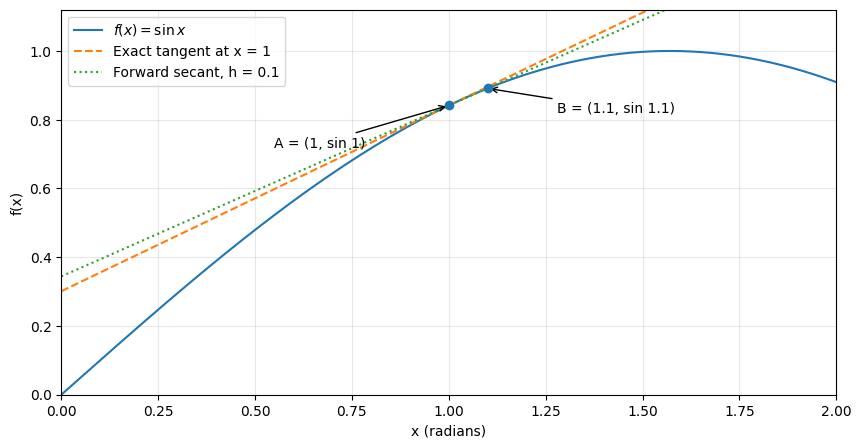

Exact tangent slope = 0.5403023058681398
Forward secant slope = 0.49736375253538867


In [11]:
xs = np.linspace(0.0, 2.0, 700)

xA, xB = 1.0, 1.1
yA, yB = np.sin(xA), np.sin(xB)

m_tan = np.cos(xA)
m_sec = (yB - yA) / (xB - xA)

tangent = yA + m_tan*(xs - xA)
secant = yA + m_sec*(xs - xA)

plt.figure(figsize=(10, 5))
plt.plot(xs, np.sin(xs), label=r'$f(x)=\sin x$')
plt.plot(xs, tangent, '--', label='Exact tangent at x = 1')
plt.plot(xs, secant, ':', label='Forward secant, h = 0.1')
plt.scatter([xA, xB], [yA, yB], zorder=5)

plt.annotate('A = (1, sin 1)', (xA, yA), xytext=(0.55, 0.72),
             arrowprops=dict(arrowstyle='->'))
plt.annotate('B = (1.1, sin 1.1)', (xB, yB), xytext=(1.28, 0.82),
             arrowprops=dict(arrowstyle='->'))

plt.xlim(0, 2)
plt.ylim(0, 1.12)
plt.xlabel('x (radians)')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Exact tangent slope =", m_tan)
print("Forward secant slope =", m_sec)

### Read the graph mathematically

At point $A$, the curve, tangent and secant all meet.

At point $B$:

- the sine curve and the forward secant meet;
- the exact tangent does **not** have to pass through $B$.

If we repeatedly reduce $h$, point $B$ moves toward $A$. In exact mathematics, the secant slope approaches the tangent slope if the derivative exists.

That statement naturally raises our next question:

> **Should we therefore make $h$ as tiny as possible on a computer?**

## 8. Step size and the two competing sources of error

A finite-difference derivative has two important practical error mechanisms.

### 1. Truncation error

The formula uses a finite interval instead of the mathematical limit. If $h$ is too large, the secant spans too much of the curve and is not sufficiently local.

For smooth functions:

$$
E_{\text{forward}}\sim O(h),
\qquad
E_{\text{central}}\sim O(h^2)
$$

in the truncation-dominated regime.

### 2. Floating-point roundoff and cancellation

If $h$ becomes extremely small, quantities such as $f(x+h)$ and $f(x)$ become almost equal in computer arithmetic. Subtracting nearly equal stored values can destroy relative precision.

Therefore, the practical error often follows this qualitative pattern:

$$
\text{large }h
\;\rightarrow\;
\text{truncation error}
\;\rightarrow\;
\text{low-error region}
\;\rightarrow\;
\text{roundoff/cancellation at tiny }h.
$$

### Predict before running

Do you expect the error to decrease monotonically all the way to $h=10^{-15}$?

- No. The error will not keep decreasing all the way to h = 10⁻¹⁵.

This is because as h shrinks from 0.1, truncation error falls, so at first the error drops (by about 10× per step for forward, about 100× per step for central). But once h is very small, f(x + h) and f(x) are nearly equal, and subtracting them in float64 wipes out most of the significant digits (cancellation). Dividing by a tiny h then magnifies the rounding error. So the error reaches a minimum at some moderate h and then rises again as h keeps shrinking.

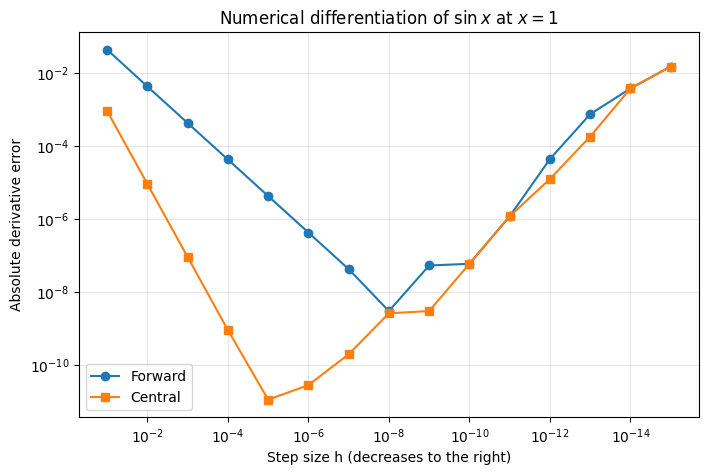

Best sampled h on this runtime:
  Forward: 1e-08
  Central: 1e-05


In [12]:
hs = np.logspace(-1, -15, 15)

fwd_vals = (np.sin(1 + hs) - np.sin(1)) / hs
ctr_vals = (np.sin(1 + hs) - np.sin(1 - hs)) / (2*hs)

ef = np.abs(fwd_vals - np.cos(1))
ec = np.abs(ctr_vals - np.cos(1))

plt.figure(figsize=(8, 5))
plt.loglog(hs, ef, 'o-', label='Forward')
plt.loglog(hs, ec, 's-', label='Central')
plt.gca().invert_xaxis()
plt.xlabel('Step size h (decreases to the right)')
plt.ylabel('Absolute derivative error')
plt.title(r'Numerical differentiation of $\sin x$ at $x=1$')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

best_f = hs[np.argmin(ef)]
best_c = hs[np.argmin(ec)]

print("Best sampled h on this runtime:")
print("  Forward:", best_f)
print("  Central:", best_c)

In [13]:
# Check the expected convergence order in the large-h / truncation-dominated region.
# The log-log slope should be near 1 for forward difference and near 2 for central difference.

slope_forward = np.polyfit(np.log10(hs[:4]), np.log10(ef[:4]), 1)[0]
slope_central = np.polyfit(np.log10(hs[:4]), np.log10(ec[:4]), 1)[0]

print("Observed forward error slope:", slope_forward)
print("Observed central error slope:", slope_central)

assert 0.8 < slope_forward < 1.2
assert 1.8 < slope_central < 2.2

Observed forward error slope: 1.0027318905612972
Observed central error slope: 1.9999453615526093


### Interpretation task

In a new Markdown cell, explain the graph in three regions:

1. **Large $h$:** why is the estimate poor?
2. **Intermediate $h$:** why does a low-error region appear?
3. **Extremely small $h$:** why does decreasing $h$ stop helping?

Also explain why the “best” sampled $h$ printed above should **not** be treated as a universal constant. It depends on the function, scale, floating-point precision and implementation.

### Interpretation of the error graph

**1. Large h (h ≈ 10⁻¹ to 10⁻³): the estimate is poor because of truncation error.**

Large h leaves too much truncation error, because the secant isn't local;

The secant joins two points that are far apart, so it captures the average slope over a wide stretch of the curve instead of the local slope at x = 1. This is truncation error: the finite-difference formula replaces the limit h → 0 with a finite step. In this region the error falls in a straight line on the log-log plot. The fitted slopes were ≈ 1.00 for forward and ≈ 2.00 for central, confirming that forward error is O(h) and central error is O(h²). Central is therefore far more accurate for the same h (≈ 9×10⁻⁴ vs ≈ 4×10⁻² at h = 0.1).

**2. Intermediate h: a low-error region appears because the two error sources are balanced.**

Intermediate h is where truncation and roundoff balance, giving minimum error;

As h shrinks, truncation error keeps decreasing, while roundoff error is still small. The total error reaches its minimum where the two are roughly equal: about 3×10⁻⁹ at h = 10⁻⁸ for forward, and about 10⁻¹¹ at h = 10⁻⁵ for central. Central reaches its best point at a larger h because its truncation error falls faster, so it hits the balance point earlier and achieves a lower minimum error.

**3. Extremely small h (h below ≈ 10⁻⁸): decreasing h stops helping because of floating-point cancellation.**

Tiny h brings subtractive cancellation, and dividing by h amplifies rounding error;

float64 stores only about 16 significant digits. When h is tiny, f(x+h) and f(x) (or f(x−h)) are almost identical, so subtracting them cancels most of their digits and leaves mainly rounding noise. Dividing this noisy difference by a tiny h magnifies it, so the error grows as h decreases. The curve becomes jagged, and at h = 10⁻¹⁵ the error (≈ 10⁻²) is as bad as with h = 0.1. Both methods behave similarly here because roundoff, not the formula, now dominates.

**Why the "best" h is not a universal constant**

The best h depends on the function's derivatives, scaling, precision and implementation, so it isn't universal;

The optimal h comes from balancing truncation error against roundoff error, and both depend on the specific situation:
- **The function:** truncation error depends on its higher derivatives (f'' for forward, f''' for central), which differ between functions and between points.
- **Scale:** if x or f(x) is very large or small, the absolute size of rounding errors changes, which shifts the balance point.
- **Floating-point precision:** in float32 (≈ 7 digits) roundoff sets in much earlier, so the best h would be much larger.
- **Implementation:** the order of operations, the formula used, and how f is computed all affect rounding.

So h = 10⁻⁸ (forward) and h = 10⁻⁵ (central) were best *for sin x at x = 1 in float64 on this runtime*. They are useful rules of thumb, but not constants to reuse blindly.

## 9. Inspecting floating-point cancellation directly

Computers normally represent real numbers using finite-precision floating-point formats. NumPy commonly uses IEEE 754 `float64`.

For the forward formula,

$$
\frac{f(x+h)-f(x)}{h},
$$

the numerator becomes very small when $h$ is tiny.

If the two stored values are almost equal, most leading digits cancel during subtraction. The small remainder can have poor **relative** accuracy, and division by a tiny $h$ magnifies the effect.

This is why

$$
h\to0
$$

in the mathematical definition of the derivative does **not** mean “choose the smallest floating-point number available.”

In [14]:
h_tiny = 1e-15

a = np.sin(1 + h_tiny)
b0 = np.sin(1.0)
difference = a - b0
estimate = difference / h_tiny

print("sin(1+h)          =", repr(a))
print("sin(1)            =", repr(b0))
print("stored difference =", repr(difference))
print("derivative estimate =", estimate)
print("exact derivative    =", np.cos(1))
print("absolute error      =", abs(estimate - np.cos(1)))

sin(1+h)          = np.float64(0.8414709848078971)
sin(1)            = np.float64(0.8414709848078965)
stored difference = np.float64(5.551115123125783e-16)
derivative estimate = 0.5551115123125783
exact derivative    = 0.5403023058681398
absolute error      = 0.014809206444438505


In [15]:
# How finely can float64 represent numbers near 1.0?
print("Machine epsilon:", np.finfo(float).eps)
print("Spacing near 1.0:", np.spacing(1.0))
print("1 + spacing(1.0) =", repr(1.0 + np.spacing(1.0)))

Machine epsilon: 2.220446049250313e-16
Spacing near 1.0: 2.220446049250313e-16
1 + spacing(1.0) = np.float64(1.0000000000000002)


## Mini-recap: numerical differentiation

We have built a complete chain of reasoning:

$$
\text{sampled values}
\rightarrow
\text{secant slope}
\rightarrow
\text{tangent approximation}
\rightarrow
\text{finite differences}
\rightarrow
\text{error analysis}.
$$

The main lessons are:

- derivatives estimate **local rates of change**;
- forward and backward differences are one-sided;
- central difference uses symmetric information;
- for smooth functions, central difference has a smaller leading truncation error;
- smaller $h$ helps only until floating-point effects become significant;
- numerical results must be interpreted in the context of sampling, assumptions and computer arithmetic.

We now reuse the same derivative idea in machine learning.

# Part II - From a physical derivative to machine-learning gradients

## 10. One derivative, many partial derivatives, one gradient

For one input variable,

$$
P=P(t),
$$

the derivative

$$
\frac{dP}{dt}
$$

measures how power changes with time.

Suppose instead that power is modeled as a function of several inputs:

$$
P=P(t,T,S),
$$

where $T$ is temperature and $S$ is sunlight intensity.

Then we can ask separate sensitivity questions:

$$
\frac{\partial P}{\partial t},
\qquad
\frac{\partial P}{\partial T},
\qquad
\frac{\partial P}{\partial S}.
$$

Each is a **partial derivative**: vary one input while treating the others as fixed in that mathematical question.

Collecting the partial derivatives gives the gradient:

$$
\nabla P
=
\begin{bmatrix}
\dfrac{\partial P}{\partial t} \\[4pt]
\dfrac{\partial P}{\partial T} \\[4pt]
\dfrac{\partial P}{\partial S}
\end{bmatrix}.
$$

### Connection to machine learning

A machine-learning loss may depend on many parameters:

$$
J=J(\theta_1,\theta_2,\ldots,\theta_m).
$$

Its gradient is

$$
\nabla_{\boldsymbol{\theta}}J
=
\begin{bmatrix}
\dfrac{\partial J}{\partial\theta_1}\\
\dfrac{\partial J}{\partial\theta_2}\\
\vdots\\
\dfrac{\partial J}{\partial\theta_m}
\end{bmatrix}.
$$

So the mathematics has not changed. We still measure **sensitivity**. Only the meanings of the variables have changed.

> If temperature and sunlight themselves change with time and we want the total physical rate $dP/dt$, the chain rule combines those effects. That total derivative is different from a single partial derivative.

## 11. Regression loss as a function of one parameter

To make the ML connection visible, we use a one-parameter regression model:

$$
\hat y_i=wx_i+b.
$$

Here:

- $x_i$ is an input;
- $y_i$ is the observed target;
- $\hat y_i$ is the prediction;
- $w$ is the weight we will vary;
- $b=35$ is held fixed.

The dataset is

$$
x=[1,2,3,4,5],
\qquad
y=[42,48,55,63,70].
$$

### Why do we need a loss?

A model produces several predictions. Optimization needs a **single numerical objective** that summarizes prediction error.

We use mean squared error:

$$
J(w)
=
\frac{1}{n}
\sum_{i=1}^{n}
(wx_i+b-y_i)^2.
$$

For each observation:

1. $wx_i+b$ creates a prediction;
2. subtracting $y_i$ creates a residual;
3. squaring prevents positive and negative residuals from cancelling and penalizes large residuals more strongly;
4. averaging produces one loss value.

Now our derivative question becomes:

> **How does the loss $J$ change when the model parameter $w$ changes?**

In [16]:
x = np.array([1., 2., 3., 4., 5.])
y = np.array([42., 48., 55., 63., 70.])
b = 35.

def predict(w):
    return w*x + b

def J(w):
    return np.mean((predict(w) - y)**2)

for w in [5., 7., 9.]:
    print(f"w={w:.0f}  predictions={predict(w)}  MSE={J(w):.4f}")

w=5  predictions=[40. 45. 50. 55. 60.]  MSE=40.4000
w=7  predictions=[42. 49. 56. 63. 70.]  MSE=0.4000
w=9  predictions=[44. 53. 62. 71. 80.]  MSE=48.4000


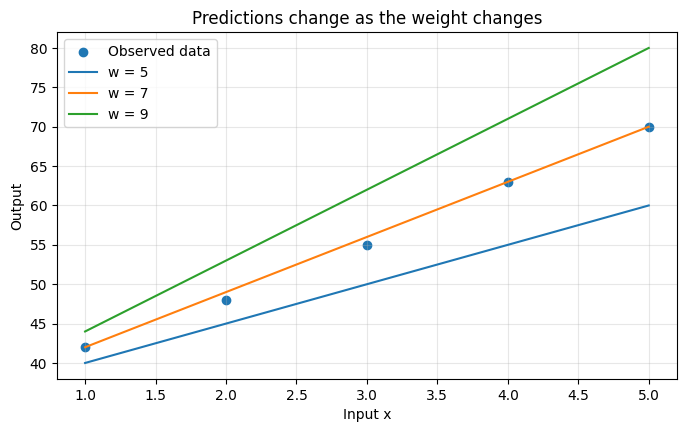

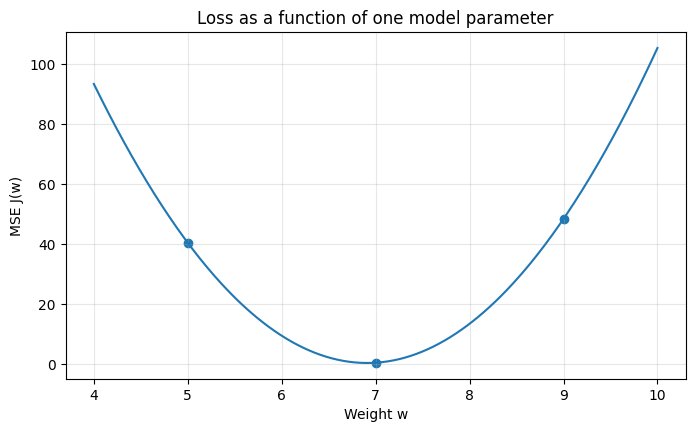

In [17]:
# See how the prediction line changes as w changes.

plt.figure(figsize=(8, 4.5))
plt.scatter(x, y, label='Observed data')

for w in [5., 7., 9.]:
    plt.plot(x, predict(w), label=f'w = {w:.0f}')

plt.xlabel('Input x')
plt.ylabel('Output')
plt.title('Predictions change as the weight changes')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Now view the loss as a function of the weight.
ws = np.linspace(4, 10, 300)
losses = np.array([J(w) for w in ws])

plt.figure(figsize=(8, 4.5))
plt.plot(ws, losses)
plt.scatter([5, 7, 9], [J(5), J(7), J(9)])
plt.xlabel('Weight w')
plt.ylabel('MSE J(w)')
plt.title('Loss as a function of one model parameter')
plt.grid(True, alpha=0.3)
plt.show()

### Concept connection: solar derivative versus ML derivative

| Solar example | ML example |
|---|---|
| Input: time $t$ | Input: model weight $w$ |
| Output: power $P(t)$ | Output: loss $J(w)$ |
| $dP/dt$ | $dJ/dw$ |
| How sensitive is power to time? | How sensitive is loss to the weight? |

The derivative operation is the same. The interpretation changes.

### Before continuing

Look at the loss graph near $w=5$. If you increase $w$ slightly, does the loss appear to rise or fall? What sign should $J'(5)$ therefore have?

If w is increased slightly from 5, the loss falls, because the curve slopes downward toward the minimum at w ≈ 7. So J′(5) should be negative.

Reason: a negative derivative means the output decreases as the input increases. Here that means that increasing w reduces the prediction error, which makes sense because the w = 5 line is too flat and needs to get steeper to fit the data.

## 12. Numerical gradient of the loss

We can apply the same central-difference idea to $J(w)$:

$$
J'(w)
\approx
\frac{J(w+h)-J(w-h)}{2h}.
$$

At $w=5$ and $h=0.01$,

$$
J'(5)
\approx
\frac{J(5.01)-J(4.99)}{0.02}.
$$

The input step is now a **parameter step**, not a time interval.

A negative result means that, locally, the loss decreases as $w$ increases.

It does **not** mean the loss itself is negative.

In [18]:
w = 5.0
h = 0.01

g_num = (J(w + h) - J(w - h)) / (2*h)

print("J(5)    =", J(5.0))
print("J(5.01) =", J(5.01))
print("J(4.99) =", J(4.99))
print("Numerical gradient at w=5 =", g_num)

assert np.isclose(g_num, -42.0, rtol=1e-10, atol=1e-10)

J(5)    = 40.4
J(5.01) = 39.98110000000002
J(4.99) = 40.82109999999998
Numerical gradient at w=5 = -41.99999999999804


### Interpret the sign

$$
J'(5)\approx-42.
$$

This means the loss curve slopes downward as $w$ increases from 5.

So, for a sufficiently small change:

$$
\text{increase }w
\quad\Rightarrow\quad
\text{decrease }J.
$$

A gradient therefore contains **directional information for optimization**.

Common mistake:

> A negative gradient is not a negative loss.  
> Here $J(5)=40.4$, while $J'(5)=-42$.

## 13. Gradient descent: using the gradient to update a parameter

A gradient points in the local direction of increasing loss. To move downhill, gradient descent moves in the opposite direction:

$$
w_{\text{new}}
=
w_{\text{old}}-\eta g,
$$

where

$$
g=J'(w)
$$

and $\eta>0$ is the **learning rate**.

At $w=5$,

$$
g=-42.
$$

With $\eta=0.01$,

$$
w_{\text{new}}
=
5-0.01(-42)
=
5.42.
$$

Because the gradient is negative, subtracting it moves $w$ upward.

### Why does the learning rate matter?

The gradient gives a **local direction**, but it does not say that an arbitrarily large move in that direction is safe.

A very large step can jump past the minimum. This is called **overshooting**.

In [19]:
eta = 0.01
w_old = 5.0
g = (J(w_old + h) - J(w_old - h)) / (2*h)
w_new = w_old - eta*g

print("w_old =", w_old, "loss =", J(w_old))
print("gradient =", g)
print("w_new =", w_new, "loss =", J(w_new))

assert J(w_new) < J(w_old)

w_old = 5.0 loss = 40.4
gradient = -41.99999999999804
w_new = 5.41999999999998 loss = 24.700400000000645


### Student experiment: test overshooting

Change the learning rate from $0.01$ to $0.1$.

Before running your experiment, predict:

1. What new weight will the update produce?
- Use the update rule with g = −42 (from Section 12):
w_new = w_old − η·g = 5 − 0.1 × (−42) = 5 + 4.2 = 9.2
2. Will the loss still decrease?
- No, it will increase. The minimum is near w = 7, and from w = 5 we only needed to move about 2 units. A step of 4.2 jumps right over the bottom of the bowl and lands on the other side, higher up than where we started. Compare J(5) = 40.4 with J(9) = 48.4 from the graph: 9.2 is even further out, so the loss will be worse.
3. If it increases, what does that tell you about the difference between a correct direction and a sensible step size?
- The gradient gave the correct direction. It said to increase w, and we did. But the step size was too large, so we overshot the minimum and the loss went up. The gradient only describes the slope locally at w = 5; it doesn't say how far away the minimum is. A correct direction guarantees improvement only for a small enough step. That's why the learning rate must be chosen carefully: too small and training is slow, too large and training overshoots, oscillates, or diverges.

In [20]:
# STUDENT TODO: experiment with a larger learning rate.
# Suggested starting value:
eta_test = 0.1

# Uncomment and complete the following lines:

w_test = w_old - eta_test*g
print("w_test =", w_test)
print("old loss =", J(w_old))
print("new loss =", J(w_test))

#print("TODO: complete the larger-learning-rate experiment above.")

w_test = 9.199999999999804
old loss = 40.4
new loss = 58.039999999990115


## 14. Gradient verification: numerical differentiation as a software check

Up to this point, numerical differentiation has been used to **estimate an unknown derivative**.

Now we use it for a second purpose:

> **independently check a derivative computed by another method.**

For the MSE loss,

$$
J(w)=
\frac1n
\sum_{i=1}^{n}
(wx_i+b-y_i)^2,
$$

differentiate with respect to $w$.

For one residual term,

$$
(wx_i+b-y_i)^2,
$$

the chain rule gives

$$
2(wx_i+b-y_i)x_i.
$$

Therefore,

$$
J'(w)
=
2\,\operatorname{mean}
\left((wx+b-y)x\right).
$$

We now compare:

- the **analytic gradient**, derived from calculus;
- the **numerical gradient**, computed from nearby loss evaluations.

If two independent paths agree closely at several test points, that is strong evidence that the implementation is consistent.

In [21]:
def analytic_grad(w):
    return 2*np.mean((w*x + b - y)*x)

def numerical_grad(w, h=1e-5):
    return (J(w + h) - J(w - h)) / (2*h)

for w in [5., 7., 9.]:
    gn = numerical_grad(w)
    ga = analytic_grad(w)
    print(f"w={w:.0f}  numerical={gn:.10f}  analytic={ga:.10f}  difference={abs(gn-ga):.3e}")
    assert np.isclose(gn, ga, rtol=1e-6, atol=1e-8)

w=5  numerical=-41.9999999995  analytic=-42.0000000000  difference=5.242e-10
w=7  numerical=1.9999999998  analytic=2.0000000000  difference=2.145e-10
w=9  numerical=45.9999999990  analytic=46.0000000000  difference=1.031e-09


### Deliberate bug

Suppose someone differentiates the squared residual but accidentally forgets the factor 2.

The resulting code may still run without any Python exception.

This is an important software-engineering lesson:

> **Code that executes successfully can still be mathematically wrong.**

The numerical gradient gives us an independent way to expose the error.

In [22]:
def buggy_grad(w):
    # Deliberately wrong: the factor 2 is missing.
    return np.mean((w*x + b - y)*x)

print("Numerical gradient at w=5:", numerical_grad(5.0))
print("Correct analytic gradient:", analytic_grad(5.0))
print("Buggy analytic gradient:", buggy_grad(5.0))

Numerical gradient at w=5: -41.99999999947579
Correct analytic gradient: -42.0
Buggy analytic gradient: -21.0


### Why not use numerical gradients for normal neural-network training?

For one parameter, the numerical check is cheap.

For a model with millions of parameters, centered finite differences would require roughly two extra loss evaluations for every parameter being checked. That is far too expensive for normal training.

Backpropagation / automatic differentiation computes the full gradient much more efficiently.

So:

- **automatic differentiation/backpropagation:** normal training;
- **finite differences:** independent verification and debugging.

Also remember that gradient checking provides **evidence**, not a mathematical proof. A check can be affected by an unsuitable $h$, nondifferentiability, inconsistent loss calculations or stochastic model behaviour.

## 15. Relative discrepancy for gradient checks

An absolute difference alone can be misleading.

A difference of $10^{-4}$:

- may be tiny if both gradients are around $1000$;
- may be enormous if both gradients are around $10^{-5}$.

A scale-aware diagnostic is

$$
r=
\frac{|g_a-g_n|}
{\max(\epsilon,|g_a|,|g_n|)},
$$

where:

- $g_a$ is the analytic gradient;
- $g_n$ is the numerical gradient;
- $\epsilon$ is a small safeguard against division by zero.

The purpose is to judge disagreement relative to the scale of the quantities being compared.

In [23]:
def relative_discrepancy(ga, gn, eps=1e-12):
    return abs(ga - gn) / max(eps, abs(ga), abs(gn))

for w in [5., 7., 9.]:
    ga = analytic_grad(w)
    gn = numerical_grad(w)
    print(f"w={w:.0f}  relative discrepancy={relative_discrepancy(ga, gn):.3e}")

w=5  relative discrepancy=1.248e-11
w=7  relative discrepancy=1.072e-10
w=9  relative discrepancy=2.241e-11


## Mini-recap: from derivative to optimization

The mathematical idea has remained consistent:

$$
\text{change an input slightly}
\rightarrow
\text{observe output change}
\rightarrow
\text{estimate sensitivity}.
$$

For the solar system:

$$
\frac{dP}{dt}
$$

measures physical change.

For the ML model:

$$
\frac{dJ}{dw}
$$

measures loss sensitivity.

Gradient descent then uses that sensitivity to update parameters, while gradient checking uses finite differences to test whether a separate derivative implementation is credible.

# Part III - From local change to accumulated quantity

## 16. Numerical integration: from power to energy

Differentiation asks:

> **How quickly is a quantity changing locally?**

Integration asks:

> **How much has accumulated over an interval?**

Power is a rate of energy generation.

If power were constant,

$$
E=P\Delta t.
$$

The units confirm the relationship:

$$
\text{W}\times\text{h}=\text{Wh}.
$$

When power varies continuously,

$$
E=\int P(t)\,dt.
$$

But our solar system gives only sampled values, not an exact function $P(t)$. We therefore approximate the area under the power-time curve numerically.

## 17. Trapezoidal rule: linear interpolation becomes area

There is a useful connection to the beginning of the notebook.

Linear interpolation assumes a straight line between two sampled points.

The area under that straight segment forms a **trapezoid**.

For one interval,

$$
E_i
\approx
(t_{i+1}-t_i)
\frac{P_i+P_{i+1}}{2}.
$$

For several intervals,

$$
E
\approx
\sum_i
(t_{i+1}-t_i)
\frac{P_i+P_{i+1}}{2}.
$$

Notice that each interval has its own width $t_{i+1}-t_i$. Therefore, this general trapezoidal formula can handle unequal sampling intervals.

In [24]:
time = np.array([10., 11., 13., 14.])
power = np.array([420., 510., 680., 620.])

interval_energy = []

for i in range(len(time)-1):
    dt = time[i+1] - time[i]
    avg_power = (power[i] + power[i+1]) / 2
    energy = dt * avg_power
    interval_energy.append(energy)
    print(f"{time[i]:.0f}:00-{time[i+1]:.0f}:00  "
          f"dt={dt:.1f} h  avg power={avg_power:.1f} W  energy={energy:.1f} Wh")

total_energy = sum(interval_energy)

print("\nTotal =", total_energy, "Wh")
print("Total =", total_energy/1000, "kWh")

assert np.isclose(total_energy, 2305.0)

10:00-11:00  dt=1.0 h  avg power=465.0 W  energy=465.0 Wh
11:00-13:00  dt=2.0 h  avg power=595.0 W  energy=1190.0 Wh
13:00-14:00  dt=1.0 h  avg power=650.0 W  energy=650.0 Wh

Total = 2305.0 Wh
Total = 2.305 kWh


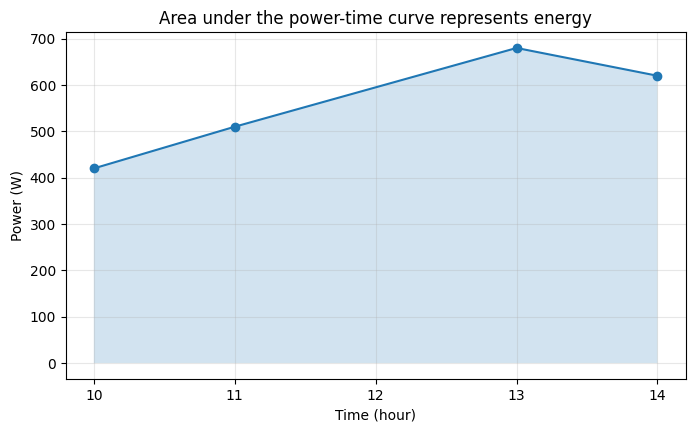

In [25]:
# Visualize the area represented by the piecewise-linear approximation.

dense_t = np.linspace(10, 14, 400)
dense_p = np.interp(dense_t, time, power)

plt.figure(figsize=(8, 4.5))
plt.plot(time, power, 'o-')
plt.fill_between(dense_t, dense_p, 0, alpha=0.2)
plt.xlabel('Time (hour)')
plt.ylabel('Power (W)')
plt.title('Area under the power-time curve represents energy')
plt.xticks([10, 11, 12, 13, 14])
plt.grid(True, alpha=0.3)
plt.show()

### Interpret the result

$$
E\approx2305\text{ Wh}=2.305\text{ kWh}.
$$

This is the estimated energy generated only during the observed interval from 10:00 to 14:00.

Its reliability depends on:

- the accuracy of the sensor;
- the sampling frequency;
- the assumption that straight segments reasonably represent the behaviour between observations.

### Important connection

Inserting the interpolated noon point $595\text{ W}$ does not change the trapezoidal total between 11:00 and 13:00, because that point lies on the same straight segment. Splitting one trapezoid into two along the same line does not change its combined area.

## 18. Simpson's rule: using curvature

The trapezoidal rule uses straight-line segments.

Simpson's $1/3$ rule uses local quadratic interpolation, which can represent curvature.

For equally spaced samples with an even number $m$ of subintervals,

$$
S=
\frac{h}{3}
\left[
f_0+4f_1+2f_2+\cdots+4f_{m-1}+f_m
\right].
$$

### Why use another benchmark problem?

As with the $\sin x$ derivative experiment, we want an exact answer for comparison.

Choose

$$
f(x)=x^2
$$

on $[0,2]$. The exact integral is

$$
\int_0^2 x^2\,dx
=
\frac{8}{3}.
$$

Using the equally spaced grid

$$
0,\;0.5,\;1,\;1.5,\;2
$$

gives four equal subintervals, so the standard composite Simpson $1/3$ rule applies.

In [26]:
xb = np.array([0., 0.5, 1., 1.5, 2.])
fb = xb**2
h_simpson = 0.5

trap = h_simpson * (
    0.5*fb[0] + fb[1] + fb[2] + fb[3] + 0.5*fb[4]
)

simp = h_simpson/3 * (
    fb[0] + 4*fb[1] + 2*fb[2] + 4*fb[3] + fb[4]
)

exact_int = 8/3

print("Exact integral =", exact_int)
print("Trapezoidal    =", trap, "absolute error =", abs(trap - exact_int))
print("Simpson        =", simp, "absolute error =", abs(simp - exact_int))

assert np.isclose(trap, 2.75)
assert np.isclose(simp, exact_int)

Exact integral = 2.6666666666666665
Trapezoidal    = 2.75 absolute error = 0.08333333333333348
Simpson        = 2.6666666666666665 absolute error = 0.0


### Why is Simpson exact here?

$x^2$ is a polynomial of degree 2. Simpson's rule is exact in exact arithmetic for polynomial integrands through degree 3 when its spacing requirements are satisfied.

### Why not apply the standard Simpson formula directly to the solar times?

The observed times are

$$
10,\;11,\;13,\;14,
$$

with interval widths

$$
1,\;2,\;1.
$$

They are not equally spaced.

We could insert the interpolated noon value to create an equally spaced grid, but that noon value is assumed rather than observed. A formally higher-order method does not automatically make uncertain input data more trustworthy.

This is another important numerical principle:

> **Method order and data quality are different issues.**

# Part IV - Independent practice

## 19. Mini-capstone: test a new function

Consider

$$
f(x)=e^{-x}\sin(2x).
$$

Your task is to apply the reasoning developed in this notebook to a new function.

### Tasks

1. Derive the analytic derivative $f'(x)$ using the product rule and chain rule.
2. Evaluate the exact derivative at $x=1$.
3. Use at least eight values of $h$.
4. Compute forward- and central-difference estimates.
5. Plot absolute error against $h$ on logarithmic axes.
6. Identify the lowest-error sampled $h$ for each method.
7. Explain the large-$h$, intermediate-$h$ and tiny-$h$ regions.
8. Comment on whether the observed truncation-dominated error behaviour is consistent with $O(h)$ and $O(h^2)$.

Do not simply report which line is lower. Explain **why the graph has the shape it has**.

In [ ]:
# STUDENT TODO - complete the mini-capstone.

# Suggested start:
# f_new = lambda z: np.exp(-z) * np.sin(2*z)
# hs_new = np.logspace(-1, -12, 12)
#
# 1. Write the analytic derivative.
# 2. Evaluate it at x=1.
# 3. Compute forward and central estimates.
# 4. Compute absolute errors.
# 5. Plot error versus h.
# 6. Interpret the graph.

print("TODO: complete the independent mini-capstone.")

TODO: complete the independent mini-capstone.


Exact derivative f'(1) = -0.6406955606

       h |  forward error |  central error
--------------------------------------------
   1e-01 |      1.317e-02 |      6.636e-03
   1e-02 |      1.890e-03 |      6.643e-05
   1e-03 |      1.949e-04 |      6.643e-07
   1e-04 |      1.955e-05 |      6.643e-09
   1e-05 |      1.956e-06 |      6.845e-11
   1e-06 |      1.955e-07 |      1.016e-11
   1e-07 |      1.989e-08 |      9.343e-11
   1e-08 |      2.869e-09 |      2.869e-09
   1e-09 |      1.026e-07 |      4.709e-08
   1e-10 |      2.691e-07 |      2.691e-07
   1e-11 |      2.506e-06 |      2.506e-06
   1e-12 |      6.966e-05 |      1.415e-05


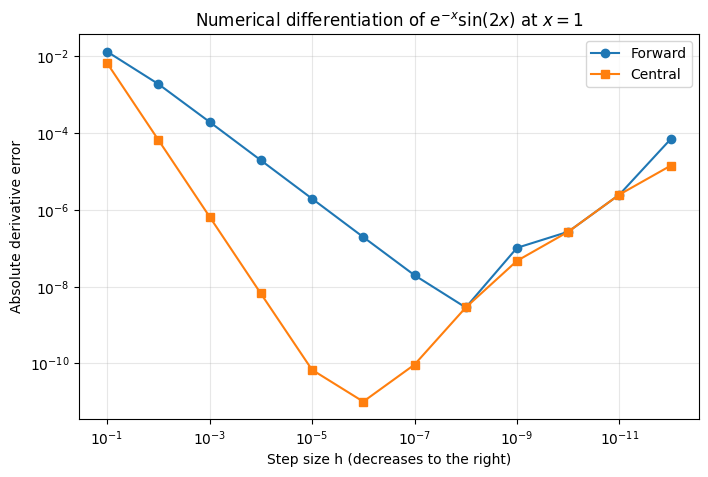

Best sampled h:
  Forward: 1e-08  (error 2.87e-09)
  Central: 1e-06  (error 1.02e-11)

Forward error slope (large h): 0.947
Central error slope (large h): 2.000


In [27]:
# Mini-capstone: f(x) = e^(-x) sin(2x)

# The function and its analytic derivative (Task 1)
f_new = lambda z: np.exp(-z) * np.sin(2*z)
f_new_prime = lambda z: np.exp(-z) * (2*np.cos(2*z) - np.sin(2*z))

# Task 2: exact derivative at x = 1
xc = 1.0            # named xc so we don't overwrite the regression data x
exact_new = f_new_prime(xc)
print(f"Exact derivative f'(1) = {exact_new:.10f}")

# Task 3: twelve step sizes from 1e-1 down to 1e-12
hs_new = np.logspace(-1, -12, 12)

# Task 4: forward and central estimates (reusing the functions from Section 4)
fwd_new = np.array([forward_difference(f_new, xc, h) for h in hs_new])
ctr_new = np.array([central_difference(f_new, xc, h) for h in hs_new])

# Absolute errors
ef_new = np.abs(fwd_new - exact_new)
ec_new = np.abs(ctr_new - exact_new)

# Table of results
print(f"\n{'h':>8} | {'forward error':>14} | {'central error':>14}")
print("-" * 44)
for h, e1, e2 in zip(hs_new, ef_new, ec_new):
    print(f"{h:8.0e} | {e1:14.3e} | {e2:14.3e}")

# Task 5: log-log plot
plt.figure(figsize=(8, 5))
plt.loglog(hs_new, ef_new, 'o-', label='Forward')
plt.loglog(hs_new, ec_new, 's-', label='Central')
plt.gca().invert_xaxis()
plt.xlabel('Step size h (decreases to the right)')
plt.ylabel('Absolute derivative error')
plt.title(r'Numerical differentiation of $e^{-x}\sin(2x)$ at $x=1$')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

# Task 6: best sampled h for each method
print("Best sampled h:")
print(f"  Forward: {hs_new[np.argmin(ef_new)]:.0e}  (error {ef_new.min():.2e})")
print(f"  Central: {hs_new[np.argmin(ec_new)]:.0e}  (error {ec_new.min():.2e})")

# Task 8: convergence order from the large-h region
slope_f_new = np.polyfit(np.log10(hs_new[:4]), np.log10(ef_new[:4]), 1)[0]
slope_c_new = np.polyfit(np.log10(hs_new[:4]), np.log10(ec_new[:4]), 1)[0]
print(f"\nForward error slope (large h): {slope_f_new:.3f}")
print(f"Central error slope (large h): {slope_c_new:.3f}")

### Mini-capstone Interpretation and Answers for $f(x)=e^{-x}\sin(2x)$ at $x=1$




**Task 1: Derive the analytic derivative $f'(x)$**

Given the function $f(x) = e^{-x}\sin(2x)$.
We use the product rule $(uv)' = u'v + uv'$, where:
- Let $u = e^{-x}$, so $u' = -e^{-x}$.
- Let $v = \sin(2x)$, so $v' = \cos(2x) \cdot 2 = 2\cos(2x)$ (by the chain rule).

Substituting these into the product rule:
$f'(x) = (-e^{-x})\sin(2x) + (e^{-x})(2\cos(2x))$
$f'(x) = e^{-x}(2\cos(2x) - \sin(2x))$




**Task 2: Evaluate the exact derivative at $x=1$**

Using the derived analytic derivative $f'(x) = e^{-x}(2\cos(2x) - \sin(2x))$ and evaluating at $x=1$:
$f'(1) = e^{-1}(2\cos(2) - \sin(2)) \approx -0.6406955606$.
The negative value indicates that the function $f(x)$ is decreasing at $x=1$.



**Tasks 3, 4, 5: Use at least eight values of $h$, compute estimates, and plot errors**

These tasks were implemented and executed in the preceding code cell. We used 12 values for $h$ ranging from $10^{-1}$ to $10^{-12}$, computed forward- and central-difference estimates, and plotted their absolute errors against $h$ on logarithmic axes.



**Task 6: Identify the lowest-error sampled $h$ for each method**

From the numerical results shown in the code cell and the plot:
-   **Forward Difference:** The lowest-error sampled $h$ is $10^{-8}$, with an absolute error of approximately $2.87 \times 10^{-9}$.
-   **Central Difference:** The lowest-error sampled $h$ is $10^{-6}$, with an absolute error of approximately $1.02 \times 10^{-11}$.



**Task 7: Explain the large-$h$, intermediate-$h$, and tiny-$h$ regions**

*   **Large $h$ (e.g., $h \approx 10^{-1}$ to $10^{-4}$): Truncation Error Dominance**
    In this region, the absolute error is primarily controlled by the *truncation error*. The secant line, used to approximate the tangent, is far from the true tangent because $h$ is large, leading to an inaccurate approximation. On the log-log plot, both error curves show a linear decrease as $h$ decreases.

*   **Intermediate $h$ (e.g., $h \approx 10^{-5}$ to $10^{-8}$ for central, $10^{-7}$ to $10^{-9}$ for forward): Low-Error Region**
    This is the optimal region where the truncation error has become small, and floating-point roundoff errors have not yet become dominant. The total error reaches its minimum when these two error sources are approximately balanced.

*   **Tiny $h$ (below approximately $10^{-8}$): Roundoff and Cancellation Dominance**
    As $h$ becomes extremely small, $f(x+h)$ and $f(x)$ (or $f(x-h)$) become nearly identical in computer's floating-point representation. Subtracting these nearly equal numbers leads to significant loss of precision (cancellation error). Dividing this noisy result by a very small $h$ magnifies the noise, causing the absolute error to increase again. The curves typically turn upwards and become irregular in this region.



**Task 8: Comment on whether the observed truncation-dominated error behaviour is consistent with $O(h)$ and $O(h^2)$**

Yes, the observed behavior in the truncation-dominated (large $h$) region is consistent with the theoretical $O(h)$ for forward difference and $O(h^2)$ for central difference.

-   **Forward Difference:** The log-log plot shows a slope of approximately $0.947$ for the largest $h$ values. This is close to 1, confirming the expected $O(h)$ error scaling. The slight deviation from 1 can be attributed to higher-order Taylor terms still being significant at $h=0.1$.
-   **Central Difference:** The log-log plot shows a slope of approximately $2.000$ for the largest $h$ values. This perfectly matches the expected $O(h^2)$ error scaling, indicating that halving $h$ reduces the error by roughly a factor of four.

As observed previously with $\sin(x)$, the central difference method generally achieves a lower minimum error at a larger optimal $h$ compared to the forward difference, due to its faster convergence rate in the truncation regime.

# 20. Can you now explain these ideas without looking at the formulas?

Before finishing, check whether you can explain each item in your own words:

- **Why is an interpolated value not a new observation?**

  It is calculated from existing data using an assumption (e.g. a straight line between two points), not measured by the sensor. If the assumption is wrong, for example a cloud passed at noon, the estimate is wrong and nothing in the data would reveal it. It adds no new information about the real world.

- **What is the difference between a function value and a derivative?**

  A function value tells us *how much* (e.g. $P(12)\approx595$ W). A derivative tells us *how fast it is changing* (e.g. $P'(12)\approx85$ W/h). They answer different questions and have different units.

- **Why is the derivative represented geometrically by a tangent?**

  The tangent is the straight line that touches the curve at one point and matches its direction there. Its slope equals the curve's instantaneous rate of change at that point, which is exactly the derivative.

- **Why can a secant slope approximate a tangent slope?**

  A secant joins two points on the curve. As the second point moves closer to the first ($h\to0$), the secant swings toward the tangent, and for a differentiable function its slope approaches the tangent slope. This limit is the definition of the derivative.

- **Why does central difference contain $2h$ in the denominator?**

  It uses the points $x-h$ and $x+h$, which are separated by $(x+h)-(x-h)=2h$. Slope is rise over run, and the run is $2h$.

- **What does “smooth function” mean in this context?**

  A function with no jumps, sharp corners or abrupt changes near the point of interest, so that its derivatives ($f', f'', f''', \ldots$) exist and behave regularly. Smoothness is what makes the Taylor expansion, and therefore the error analysis, valid.

- **Why does central difference usually have smaller truncation error?**

  In the Taylor expansions of $f(x+h)$ and $f(x-h)$, the $h^2$ terms are identical, so they cancel when the two are subtracted. This removes the $O(h)$ error present in forward difference and leaves a smaller $O(h^2)$ error.

- **Why does making $h$ extremely small eventually stop helping?**

  `float64` stores only about 16 significant digits. When $h$ is tiny, $f(x+h)$ and $f(x)$ are almost identical, so subtracting them cancels most of their digits and leaves mainly rounding noise. Dividing by a tiny $h$ magnifies that noise, so roundoff error grows as $h$ decreases.

- **What is the difference between $J(w)$ and $J'(w)$?**

  $J(w)$ is the loss: how wrong the model is at weight $w$ (always $\ge 0$ for MSE). $J'(w)$ is the slope of the loss: how the loss changes when $w$ changes slightly, and it can be negative. For example, $J(5)=40.4$ while $J'(5)=-42$.

- **Why does gradient descent subtract the gradient?**

  The gradient points in the direction in which the loss increases. To reduce the loss we move in the opposite direction: $w_{\text{new}} = w_{\text{old}} - \eta g$.

- **Why can an excessive learning rate increase the loss even when the gradient direction is correct?**

  The gradient describes only the local slope, not how far away the minimum is. A large step can jump past the minimum and land higher on the other side. With $\eta=0.1$, $w$ moved from 5 to 9.2 and the loss rose from 40.4 to 58.04: correct direction, but too large a step.

- **Why is numerical gradient checking useful but too expensive for ordinary large-model training?**

  It provides an independent check that can catch bugs in code that runs without errors (e.g. a missing factor of 2). But central differences need about two loss evaluations per parameter, which is far too costly for models with millions of parameters. Backpropagation computes the full gradient efficiently, so finite differences are used for verification and debugging only.

- **Why does integrating power over hours produce energy in Wh?**

  Power is the rate of energy generation, and rate $\times$ time gives the accumulated amount, so $\text{W}\times\text{h}=\text{Wh}$. When power varies, integration adds up many small power $\times$ time pieces, which is the area under the power–time curve.

- **How is the trapezoidal rule related to linear interpolation?**

  Linear interpolation assumes a straight line between neighbouring samples, and the area under each straight segment is a trapezoid. The trapezoidal rule is therefore the integral of the linear interpolation.

- **Why does the standard composite Simpson $1/3$ rule require equally spaced samples?**

  Its weights $(1,4,2,4,\ldots,4,1)$ and the factor $h/3$ are derived by fitting parabolas through points with one common spacing $h$. With unequal spacing, such as the solar times $10, 11, 13, 14$, those weights no longer apply and the formula gives incorrect results.

If any answer is still unclear, return to the corresponding experiment and connect the equation to its graph and interpretation.

# 21. Further reading and viewing

These resources are optional extensions from MIT and Stanford.

### Numerical differentiation
- [MIT OpenCourseWare - Differentiation: finite differences, Taylor error, smoothness and roundoff](https://ocw.mit.edu/courses/2-086-numerical-computation-for-mechanical-engineers-fall-2014/d25e9d10e9cd4bd5dcc66422dedc0ada_MIT2_086F14_Nutshell_Diff.pdf)

### Gradient descent
- [MIT OpenCourseWare - Gilbert Strang, Gradient Descent: Downhill to a Minimum](https://ocw.mit.edu/courses/18-065-matrix-methods-in-data-analysis-signal-processing-and-machine-learning-spring-2018/resources/lecture-22-gradient-descent-downhill-to-a-minimum/)

### Gradient checking
- [Stanford CS224N - Neural Networks, Backpropagation and Gradient Check](https://web.stanford.edu/class/cs224n/readings/cs224n-2019-notes03-neuralnets.pdf)
- [Stanford CS231n - Gradient Checking](https://cs231n.stanford.edu/slides/2016/winter1516_lecture6.pdf)

### Numerical integration
- [MIT OpenCourseWare - Session 63: Numerical Integration](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/pages/unit-3-the-definite-integral-and-its-applications/part-c-average-value-probability-and-numerical-integration/session-63-numerical-integration/)

---

**Recommended study pattern:** read the explanation, make the prediction, run the code, inspect the numerical evidence, and then explain the result in words.